# Comparisons of example plots and calculations between the `tmm` and `tmm_fast` packages

In this `IPYNB`, we demonstrate migration from `tmm` to `tmm_fast`.

This was adapted from the original `tmm` `IPYNB` at https://github.com/sbyrnes321/tmm/blob/master/examples.ipynb .

Note that only examples 1 and 2 of the original 6 could be compared. Examples 1 and 2 using only the coherent TMM. Examples 3 through 5 could not be compared because the original `tmm` capability has not been implemented in `tmm_fast`. Example 6 was not included because the underlying code in `tmm_fast` contains an error.

## Imports

for `tmm` only:

In [1]:
from __future__ import division, print_function, absolute_import

from tmm import (coh_tmm, unpolarized_RT)

from numpy import pi, linspace, inf, array
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
# %matplotlib inline

for `tmm_fast`:

In [2]:
import tmm_fast
import numpy as np

In [3]:
# "5 * degree" is 5 degrees expressed in radians
# "1.2 / degree" is 1.2 radians expressed in degrees
degree = pi/180

## Sample 1

Here's a thin non-absorbing layer, on top of a thick absorbing layer, with air on both sides. Plotting reflected intensity versus wavenumber, at two different incident angles.

`tmm` original:

In [4]:
# number of wavelength points:
nwvl = 400
# list of layer thicknesses in nm
d_list = [inf,100,300,inf]
# list of refractive indices
n_list = [1,2.2,3.3+0.3j,1]
# list of wavenumbers to plot in nm^-1
ks=linspace(0.0001,.01,num=nwvl)
# initialize lists of y-values to plot
Rnorm=[] 
R45=[]
for k in ks:
    # For normal incidence, s and p polarizations are identical.
    # I arbitrarily decided to use 's'.
    Rnorm.append(coh_tmm('s',n_list, d_list, 0, 1/k)['R'])
    R45.append(unpolarized_RT(n_list, d_list, 45*degree, 1/k)['R'])
kcm = ks * 1e7 #ks in cm^-1 rather than nm^-1

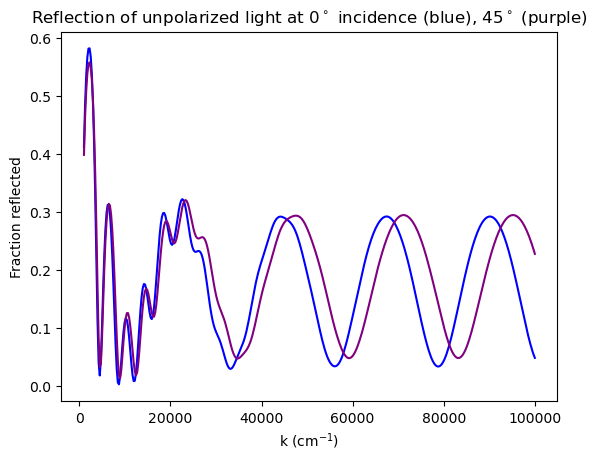

In [5]:
plt.figure()
plt.plot(kcm,Rnorm,'blue',kcm,R45,'purple')
plt.xlabel(r'k (cm$^{-1}$)')
plt.ylabel('Fraction reflected')
plt.title(r'Reflection of unpolarized light at 0$^\circ$ incidence (blue), '
            r'45$^\circ$ (purple)');

`tmm_fast`:

The final two lines show that the output arrays from the two packages are roughly identical to within numerical precision.

In [6]:
num_layers = 4
M = np.broadcast_to(np.reshape(n_list,shape=(1, num_layers, 1)), (1, num_layers, nwvl)) # M must have this shape
T = np.broadcast_to(np.reshape(d_list,shape=(1, num_layers)), (1, num_layers))
Rnormtf = tmm_fast.coh_tmm('s',M, T, np.array(0,ndmin=1), 1/ks,device='cpu')['R']
R45tfs = tmm_fast.coh_tmm('s', M, T, np.array(45*degree,ndmin=1), 1/ks, device='cpu')
R45tfp = tmm_fast.coh_tmm('p', M, T, np.array(45*degree,ndmin=1), 1/ks, device='cpu')
Ravg = 0.5*(R45tfs['R']+R45tfp['R']).flatten()
print(np.all(np.isclose(Rnorm,Rnormtf.flatten())))
print(np.all(np.isclose(R45,Ravg)))

True
True


## Sample 2

Here's the transmitted intensity versus wavelength through a single-layer
film which has some complicated wavelength-dependent index of refraction.
(I made these numbers up, but in real life they could be read out of a
graph / table published in the literature.) Air is on both sides of the
film, and the light is normally incident.

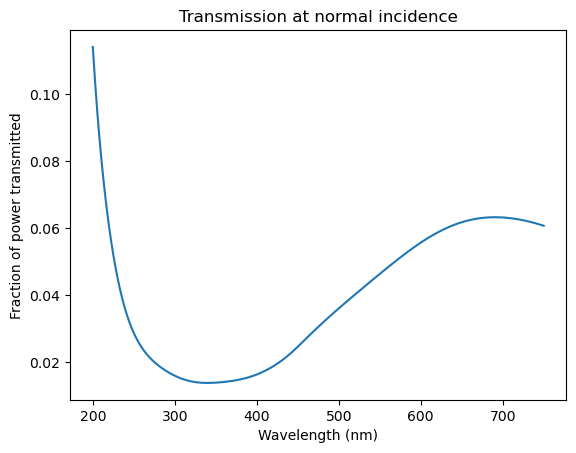

In [7]:
#index of refraction of my material: wavelength in nm versus index.
material_nk_data = array([[200, 2.1+0.1j],
                          [300, 2.4+0.3j],
                          [400, 2.3+0.4j],
                          [500, 2.2+0.4j],
                          [750, 2.2+0.5j]])
material_nk_fn = interp1d(material_nk_data[:,0].real,
                          material_nk_data[:,1], kind='quadratic')
d_list = [inf,300,inf] #in nm
lambda_list = linspace(200,750,400) #in nm
T_list = []
for lambda_vac in lambda_list:
    n_list = [1, material_nk_fn(lambda_vac), 1]
    T_list.append(coh_tmm('s',n_list,d_list,0,lambda_vac)['T'])
plt.figure()
plt.plot(lambda_list,T_list)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Fraction of power transmitted')
plt.title('Transmission at normal incidence');


`tmm_fast`:

The final line shows that the output arrays from the two packages are roughly identical to within numerical precision.

In [8]:
num_layers = len(d_list)
nwvl = len(lambda_list)
T = np.broadcast_to(np.reshape(d_list,shape=(1, num_layers)), (1, num_layers))
n_arr = material_nk_fn(lambda_list)
M = np.ones((1, num_layers, nwvl),dtype=complex)
M[0,1,:] = n_arr
Ttf = tmm_fast.coh_tmm('s',M, T, np.array(0,ndmin=1), lambda_list,device='cpu')['T']
print(np.all(np.isclose(T_list,Ttf.flatten())))

True


## Samples 3-6

Samples 3 through 5 from `tmm` are excluded because `tmm_fast` lacks some of the capabilities of `tmm`. The original example number and the missing function(s) which were to be demonstrated in that example are

|Sample|Func|
|-|-|
|3|`ellips`|
|4|`find_in_structure_with_inf`|
|4|`position_resolved`|
|5|entire `color` module|

Sample 6 is not included because a bug in `tmm_fast` keeps this example from working correctly. It will be added once [this bug](https://github.com/MLResearchAtOSRAM/tmm_fast/issues/28) is fixed.